## Supernova dataset

In [1]:
import numpy as np
import pylab as plt
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
#defining a function that computes the chi square for every fit 

def chi_square(x,y,dy,model):
    y_pred = model.predict(x.reshape(-1,1))
    return np.sum(((y - y_pred)/dy)**2)

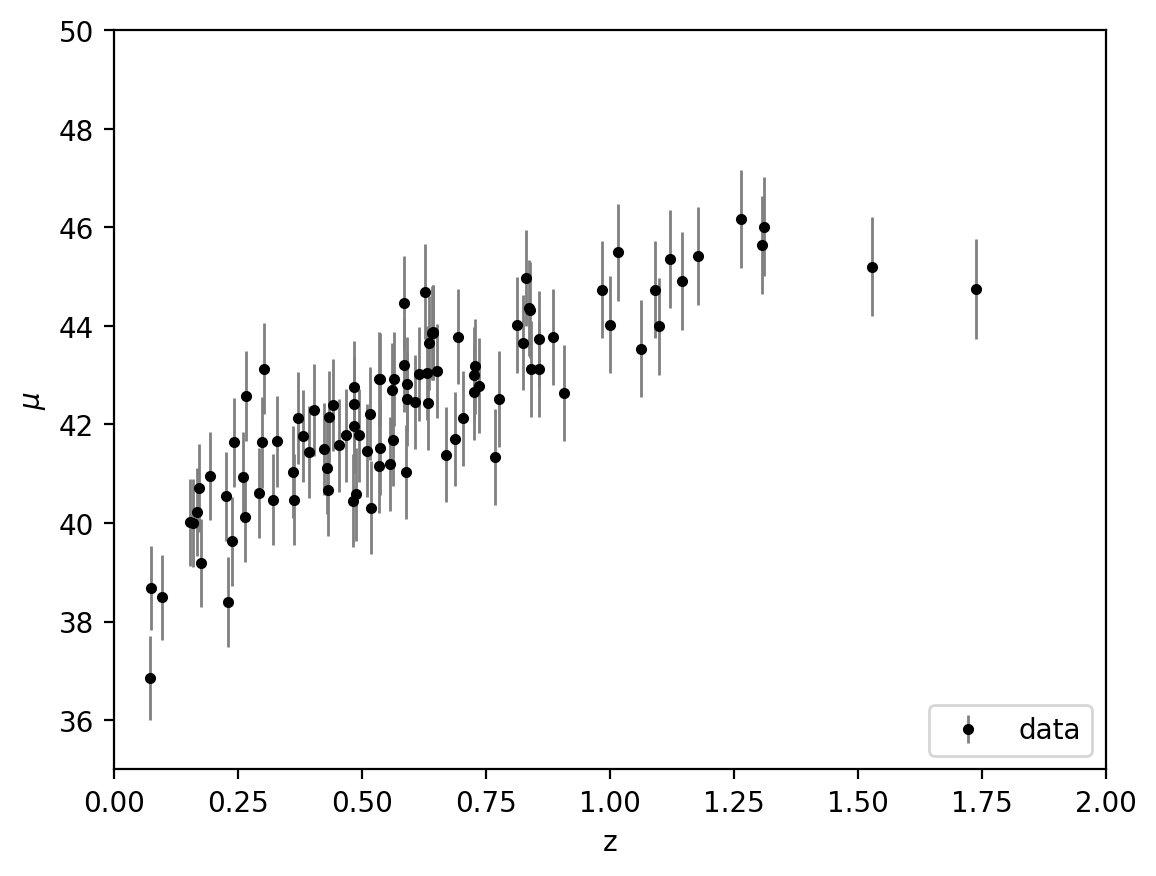

In [3]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

X = z_sample
y = mu_sample

X = X.reshape(-1,1)
y = y.reshape(-1,1)

## Fitting data with Regression

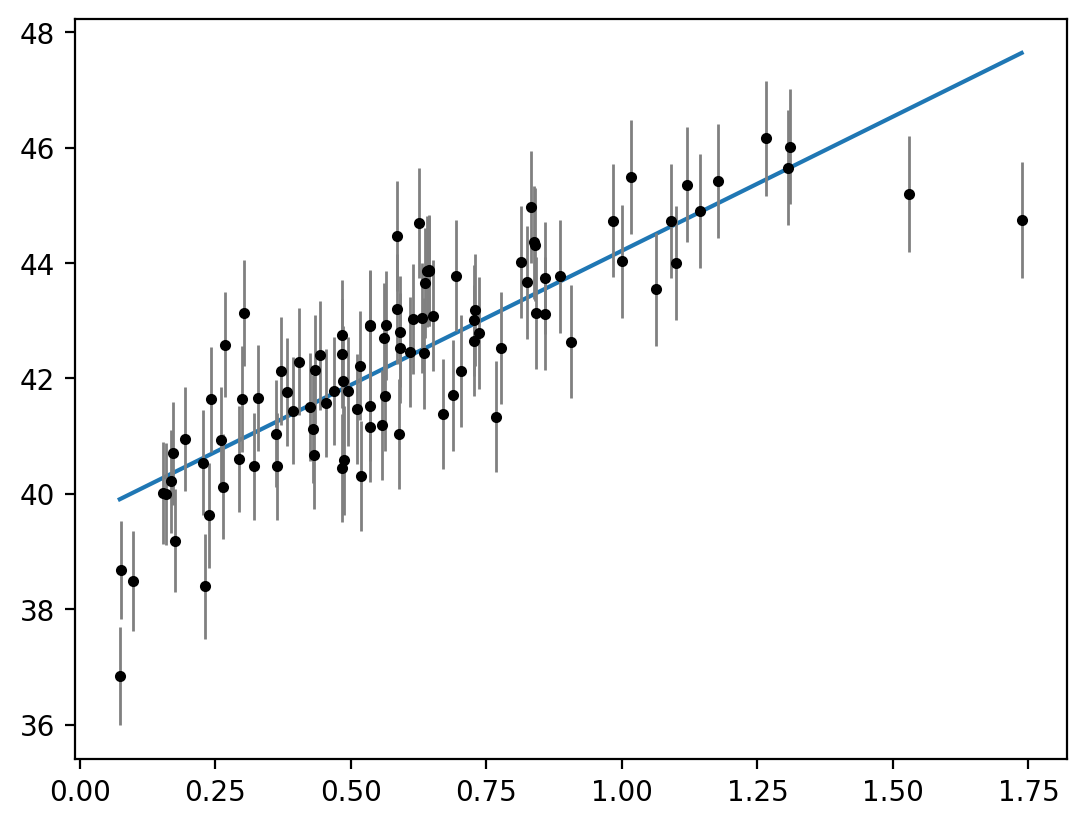

In [4]:
#trying to fit with linear function even if data doesn't seem too compatible
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X, y)

theta0 = linear.intercept_
theta1 = linear.coef_

Xgrid = np.linspace(min(z_sample) , max(z_sample) , 1000)
model = Xgrid*theta1 + theta0
model = model[0]

plt.plot(Xgrid , model)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.show()
#print(theta0 , theta1, dmu)

## Trying by taking log of y

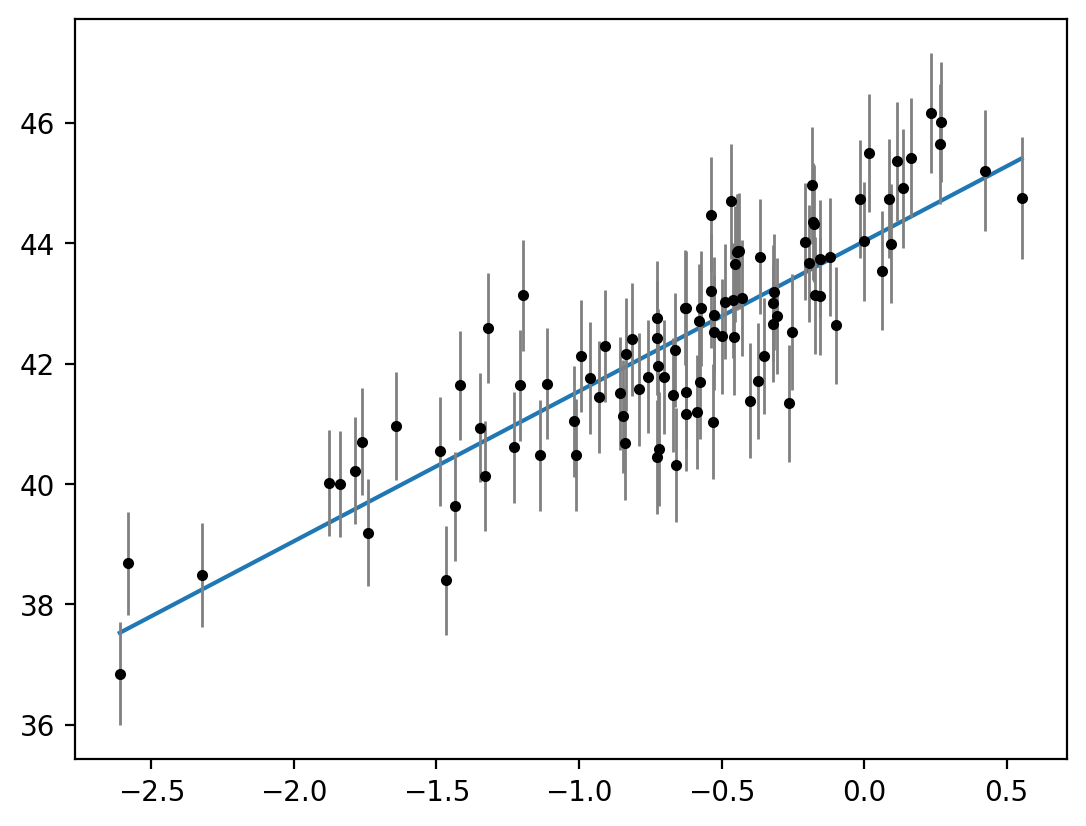

chi square =  643.93714963778


In [5]:
linear_log = LinearRegression()
linear_log.fit(np.log(X), y)

theta0_log = linear_log.intercept_
theta1_log = linear_log.coef_

Xgrid = np.linspace(min(np.log(z_sample)) , max(np.log(z_sample)) , 1000)
graph = linear_log.predict(Xgrid.reshape(-1,1))

chi_linear = chi_square(np.log(z_sample) , mu_sample, dmu, linear_log)

plt.plot(Xgrid , graph)
plt.errorbar(np.log(z_sample), mu_sample,dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.show()
print("chi square = ", chi_linear/(len(z_sample)-2))

Much Better!

## Polynomial approach

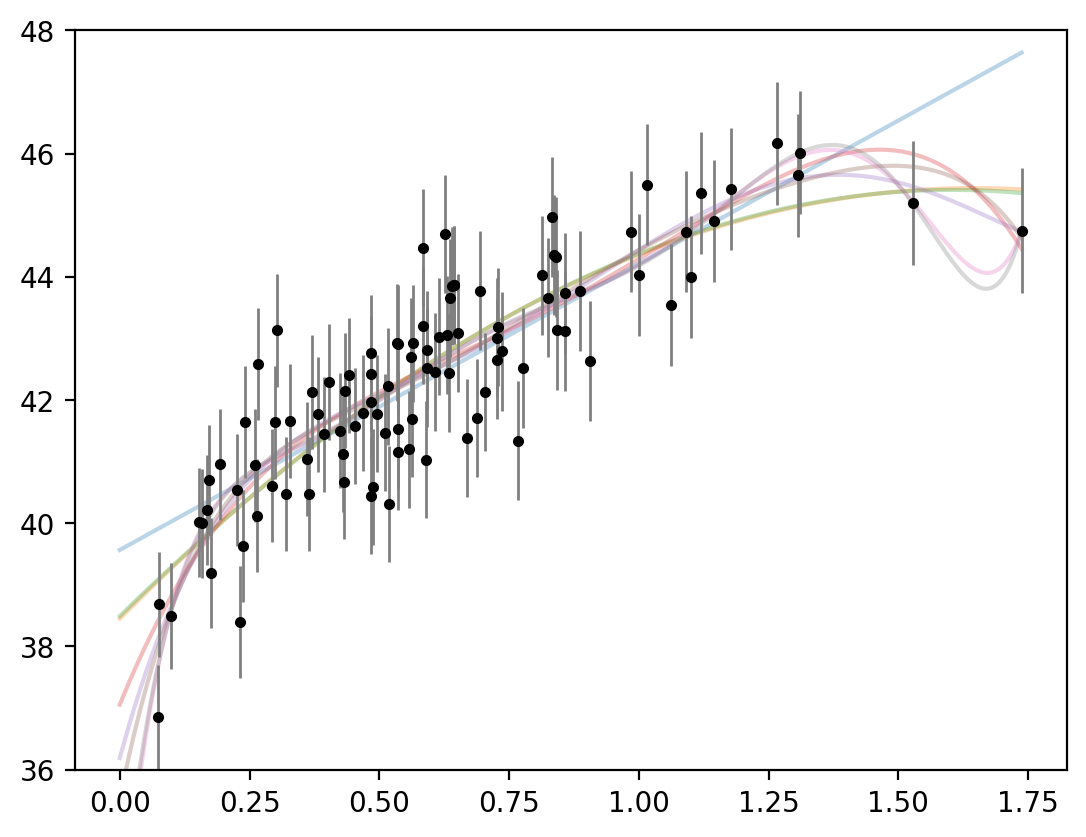

In [11]:
from astroML.linear_model import PolynomialRegression
from sklearn.model_selection import train_test_split

y = y.reshape(1,-1)[0]
Xgrid = np.linspace(0 , max(z_sample) , 1000) 

#defining max degree of the polynomial
max_degree = 8
chi = np.array([])
dof = np.size(z_sample) - 2

for degree in range (max_degree):
    model = PolynomialRegression(degree + 1) #starting with degree 1
    model.fit(X, y)

    n_constraints = degree + 1
    alpha = model.coef_
    
    #preparing the plot
    y_model = model.predict(Xgrid.reshape(-1,1))
    #model = model[0]
    chi = np.append(chi, chi_square(z_sample , mu_sample, dmu, model))
    plt.plot(Xgrid , y_model , alpha = 0.3)
    

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data') 
plt.ylim(36,48)
plt.show()

chi_reduced = chi/dof
#chi_reduced

as we can see the model starts to predict our dataset in a more precise way as we increase the degree

we can plot chi square to see the increasing of precision

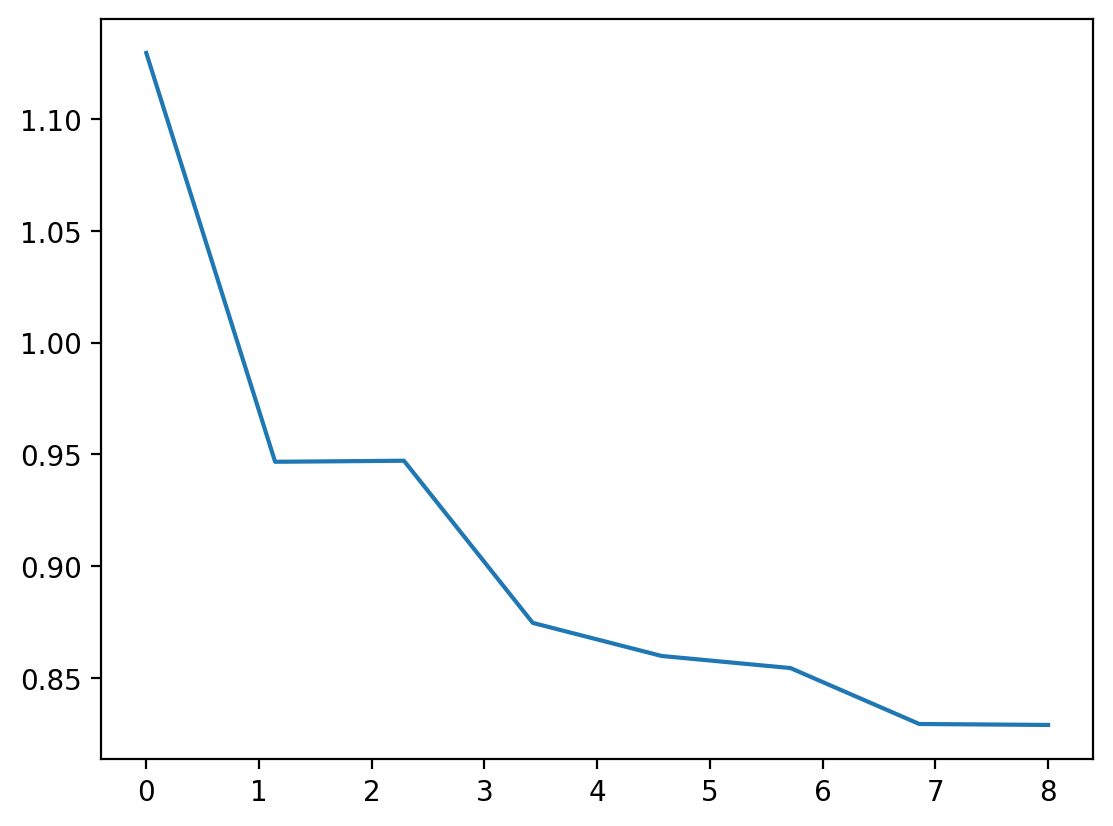

In [12]:
deg = np.linspace(0 , max_degree, max_degree)
plt.plot(deg , chi_reduced)
plt.show()

when i fit with a degree 6 polynomial, the last point begin to be exactly on the line, so i guess form there i'm overfitting
fitting with a linear function doeasn't give me a good chi square, and the function doesn't really follow the behavior of the points

In [42]:
d = np.arange(0, max_degree)

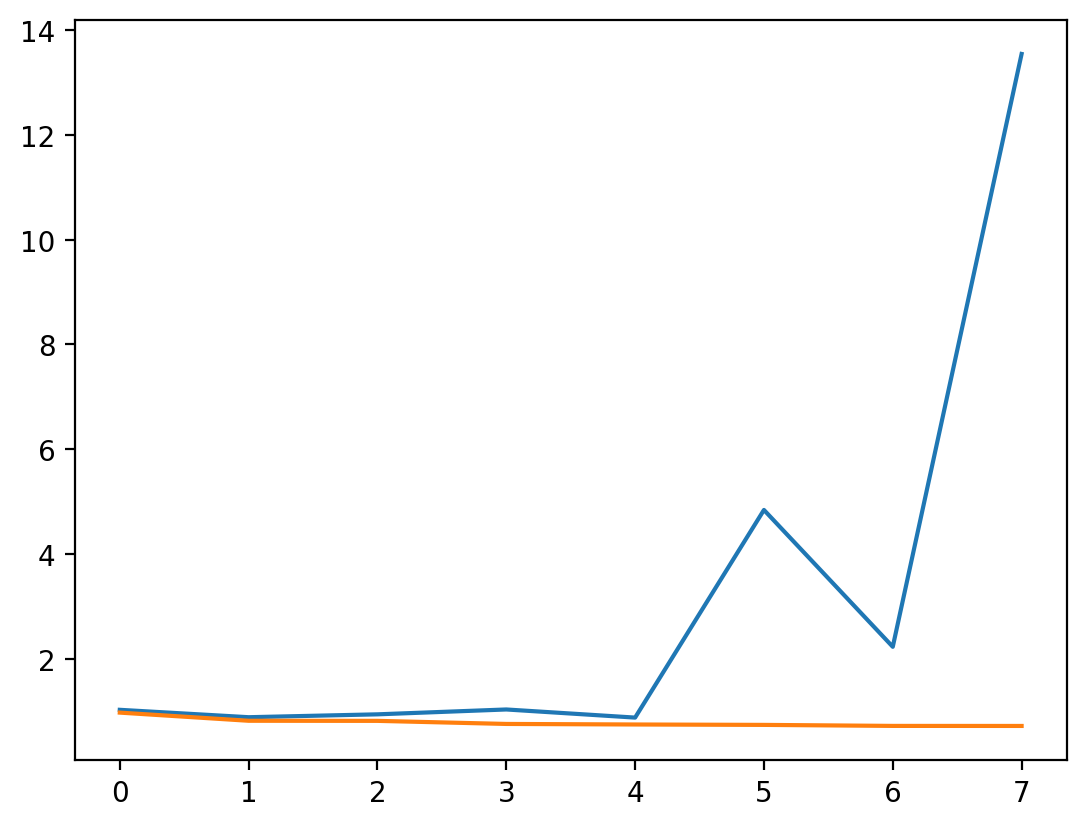

In [45]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

k = 10

test_score = np.array([])
train_score = np.array([])

for i in range (max_degree):
    
    poly = PolynomialRegression(i + 1) 
    
    k_folds = KFold(n_splits = k)
    
    cv_results =  cross_validate(poly, z_sample.reshape(-1,1), mu_sample, cv = k_folds, scoring='neg_mean_squared_error', return_train_score=True)
    test_score = np.append(test_score,- np.mean(cv_results['test_score']))
    train_score = np.append(train_score,- np.mean(cv_results['train_score']))

plt.plot(d, test_score)
plt.plot(d, train_score)


the best should be a polynomial with degree = 5

<ErrorbarContainer object of 3 artists>

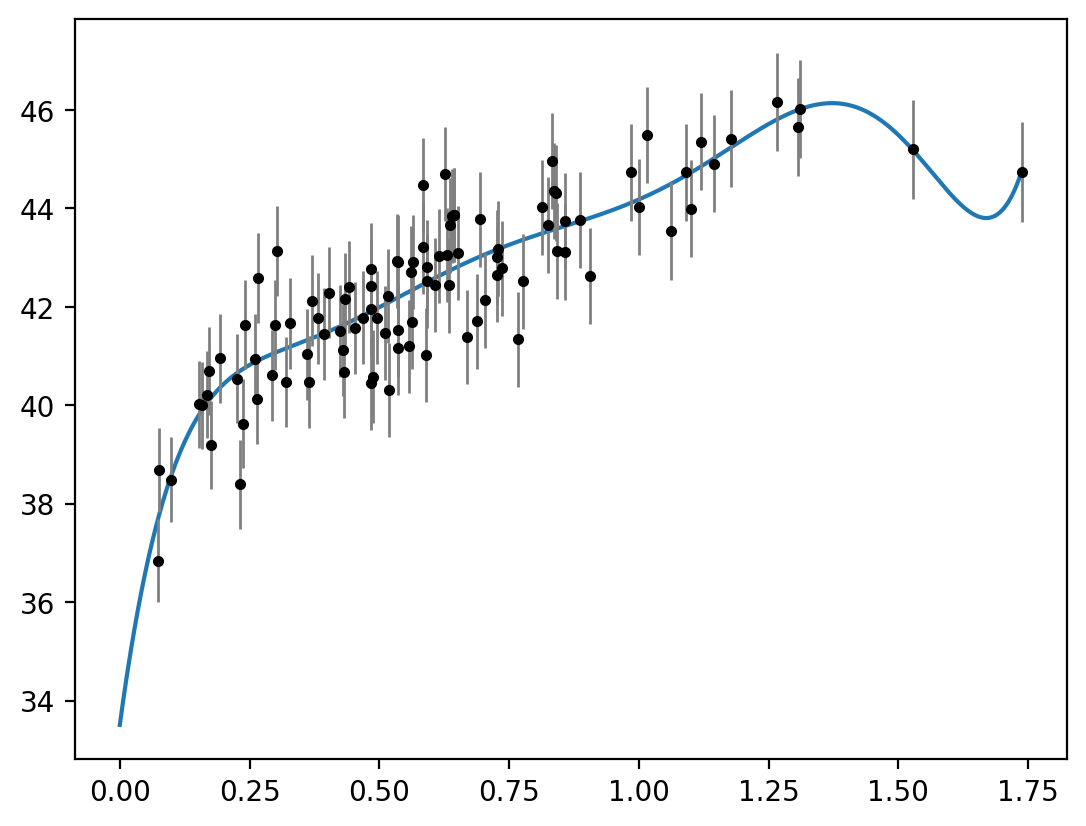

In [23]:
poly5 = PolynomialRegression(5)
poly5.fit(z_sample.reshape(-1,1), mu_sample)

Xgrid = np.linspace(0 , max(z_sample) , 1000) 
y_model = model.predict(Xgrid.reshape(-1,1))
plt.plot(Xgrid , y_model)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data') 